# QA solve CVRP
使用量子退火算法（QA）解决带容量车辆路径问题（CVRP）

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from qiskit.visualization import plot_histogram


from src.dataset_generator import CVRPDatasetGenerator, list_available_instances, load_instance
from src.cvrp_solver import CVRPSolver
from src.utils import plot_solution

plt.rcParams['font.family'] = 'SimHei'

# 1. 现成的 CVRP 数据集

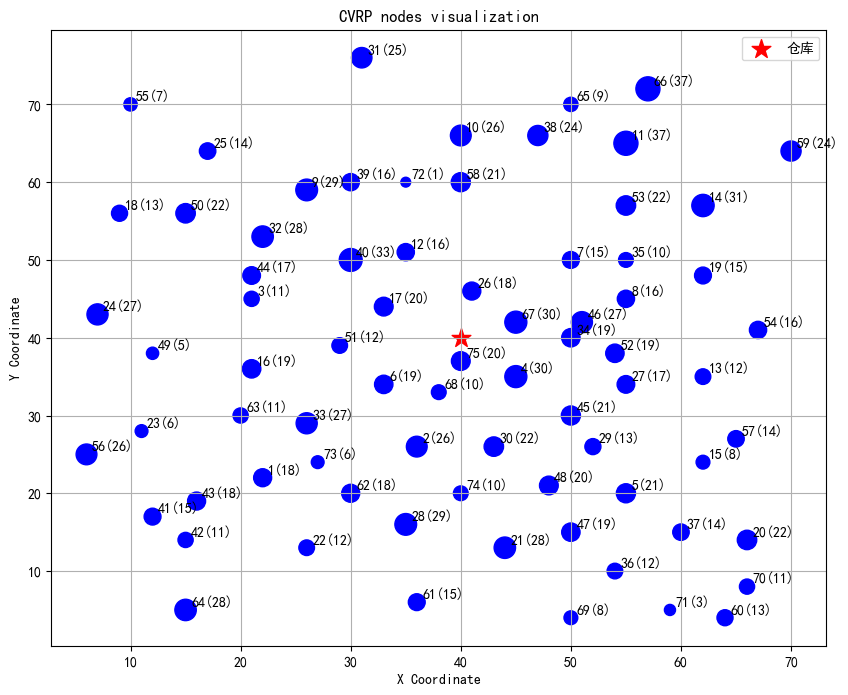

小车数量:5
小车容量:280
客户节点数量:76
客户节点位置:[[40.0, 40.0], [22.0, 22.0], [36.0, 26.0], [21.0, 45.0], [45.0, 35.0], [55.0, 20.0], [33.0, 34.0], [50.0, 50.0], [55.0, 45.0], [26.0, 59.0], [40.0, 66.0], [55.0, 65.0], [35.0, 51.0], [62.0, 35.0], [62.0, 57.0], [62.0, 24.0], [21.0, 36.0], [33.0, 44.0], [9.0, 56.0], [62.0, 48.0], [66.0, 14.0], [44.0, 13.0], [26.0, 13.0], [11.0, 28.0], [7.0, 43.0], [17.0, 64.0], [41.0, 46.0], [55.0, 34.0], [35.0, 16.0], [52.0, 26.0], [43.0, 26.0], [31.0, 76.0], [22.0, 53.0], [26.0, 29.0], [50.0, 40.0], [55.0, 50.0], [54.0, 10.0], [60.0, 15.0], [47.0, 66.0], [30.0, 60.0], [30.0, 50.0], [12.0, 17.0], [15.0, 14.0], [16.0, 19.0], [21.0, 48.0], [50.0, 30.0], [51.0, 42.0], [50.0, 15.0], [48.0, 21.0], [12.0, 38.0], [15.0, 56.0], [29.0, 39.0], [54.0, 38.0], [55.0, 57.0], [67.0, 41.0], [10.0, 70.0], [6.0, 25.0], [65.0, 27.0], [40.0, 60.0], [70.0, 64.0], [64.0, 4.0], [36.0, 6.0], [30.0, 20.0], [20.0, 30.0], [15.0, 5.0], [50.0, 70.0], [57.0, 72.0], [45.0, 42.0], [38.0, 33.0], [50.0,

In [2]:
filename = "P-n76-k5.vrp"
filedir = "CVRPLIB"
solver = CVRPSolver(filedir,filename)
solver.plot_problems_nodes()
print(f"小车数量:{solver.n_vehicles}")
print(f"小车容量:{solver.capacity}")
print(f"客户节点数量:{solver.n_nodes}")
print(f"客户节点位置:{solver.coordinates}")
print(f"客户节点需求:{solver.demands}")


生成 76 个节点的候选线路
聚类分簇成功！没有遗漏节点！
生成 74 条候选线路
候选集合数量: 74

模拟量子退火求解中...
基于path-based formulation进行问题建模，候选路径数量为74
模拟量子退火求解中...
找到 1000 个合理的解
解验证:成功
求解结果对应的路线:
选择路线: [0, 30, 74, 48, 47, 21, 36, 71, 60, 70, 20, 37, 5, 29, 15, 57, 69, 61, 0] (路线长度: 184.9583187595544)
选择路线: [0, 55, 25, 50, 18, 24, 49, 3, 44, 32, 9, 39, 72, 12, 40, 17, 51, 0] (路线长度: 160.2068674713945)
选择路线: [0, 35, 7, 8, 34, 19, 14, 53, 11, 65, 38, 58, 66, 59, 0] (路线长度: 171.37444436582086)
选择路线: [0, 2, 68, 33, 73, 62, 28, 22, 1, 43, 41, 42, 64, 56, 23, 63, 16, 0] (路线长度: 157.23171433730553)
选择路线: [0, 6, 75, 4, 67, 26, 46, 52, 27, 45, 13, 54, 10, 31, 0] (路线长度: 169.3424594365907)
路线总长度: 843.113804370666
模拟量子退火计算耗时: 1118.20 毫秒
总耗时: 2.16 秒


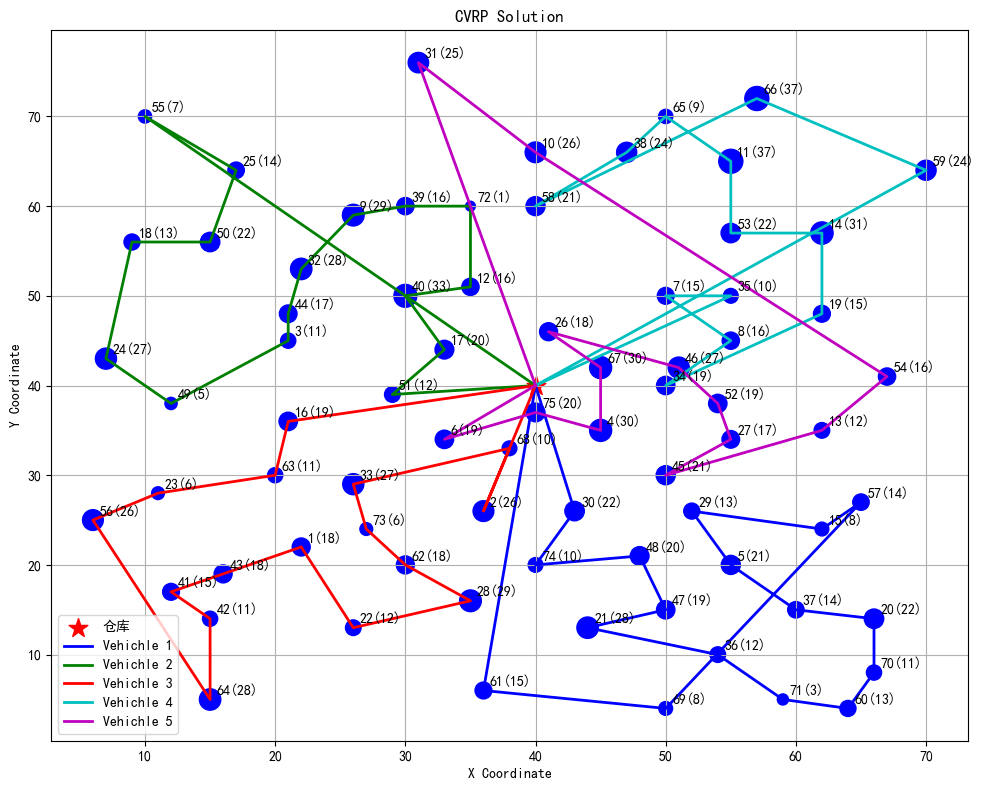

In [3]:
start_time = time.time()
# 生成候选路线和簇聚类结果
candidate_routes,clusters = solver.generate_routes("greedy")
print(f"候选集合数量: {len(candidate_routes)}")

# 量子退火求解
sa_solution, sa_result, sa_total_cost, sa_runtime = solver.solve_with_sa(candidate_routes)

end_time = time.time()
runtime = end_time-start_time
print(f"总耗时: {runtime:.2f} 秒")

# 优化路径结果可视化
solver.plot_sa_solution(sa_solution, candidate_routes)

# 2. 模拟用户自定义 CVRP 数据集

Generated dataset/generate dataset\cvrp_nodes_6_vehicles_2_instance.json


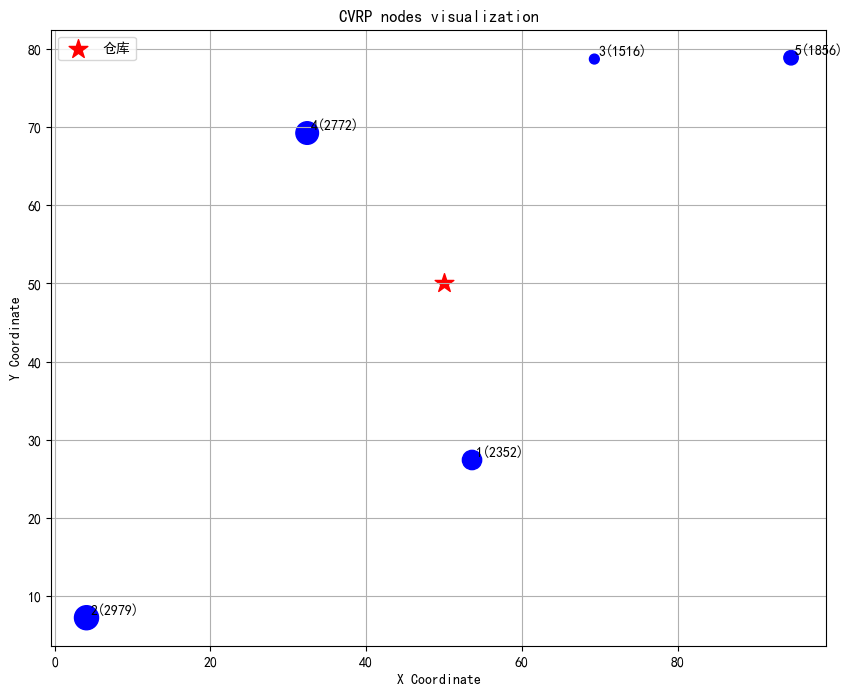

小车数量:2
小车容量:6800
客户节点数量:6
客户节点位置:[[50.0, 50.0], [53.61, 27.41], [4.1, 7.24], [69.32, 78.68], [32.44, 69.22], [94.58, 78.85]]
客户节点需求:{0: 0, 1: 2352, 2: 2979, 3: 1516, 4: 2772, 5: 1856}


In [4]:
n_nodes = 6
n_vehicles = 2

generator = CVRPDatasetGenerator()
filename = generator.generate_and_save_dataset(n_nodes=n_nodes,n_vehicles=n_vehicles)
filedir = "generate dataset"

solver = CVRPSolver(filedir,filename)
solver.plot_problems_nodes()

print(f"小车数量:{solver.n_vehicles}")
print(f"小车容量:{solver.capacity}")
print(f"客户节点数量:{solver.n_nodes}")
print(f"客户节点位置:{solver.coordinates}")
print(f"客户节点需求:{solver.demands}")

生成 6 个节点的候选线路
聚类分簇成功！没有遗漏节点！
生成 3 条候选线路
候选集合数量: 3

模拟量子退火求解中...
基于path-based formulation进行问题建模，候选路径数量为3
模拟量子退火求解中...
找到 1000 个合理的解
解验证:成功
求解结果对应的路线:
选择路线: [0, 2, 1, 0] (路线长度: 139.07)
选择路线: [0, 5, 3, 4, 0] (路线长度: 142.46)
路线总长度: 281.53
模拟量子退火计算耗时: 21.00 毫秒
总耗时: 0.03 秒


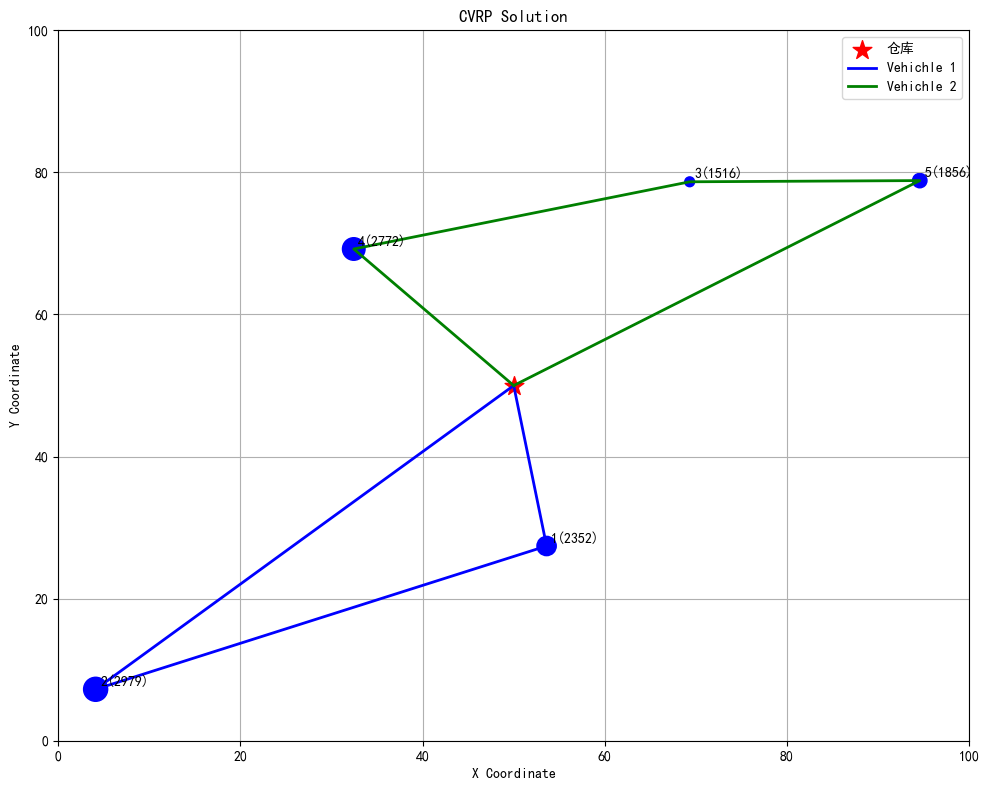

In [5]:
start_time = time.time()
# 生成候选路线和簇聚类结果
candidate_routes,clusters = solver.generate_routes("greedy")
print(f"候选集合数量: {len(candidate_routes)}")

# 量子退火求解
sa_solution, sa_result, sa_total_cost, sa_runtime = solver.solve_with_sa(candidate_routes)

end_time = time.time()
runtime = end_time-start_time
print(f"总耗时: {runtime:.2f} 秒")

# 优化路径结果可视化
solver.plot_sa_solution(sa_solution, candidate_routes)